<a href="https://colab.research.google.com/github/snaedis17/ERplus_BRCA2_TCGA_analysis/blob/main/Young_Old_fixed1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# we will use decoupler https://decoupler.readthedocs.io/en/latest/notebooks/scell/rna_psbk.html

!pip install decoupler


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.8/121.8 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.1/284.1 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 96.0 MB/s eta 0:00:00
  Created wheel for docrep: filename=docrep-0.3.2-py3-none-any.whl size=19876 sha256=c742b3f578d1e05018498de50221dd201557293c473f0d72ff0d4dd1a5044774
  Stored in directory: /root/.cache/pip/wheels/d6/19/ee/0a6a1793d91c449563b49ccab57ce52da3e6fab7614836bd8c
Successfully built docrep


In [23]:
from google.colab import files
uploaded = files.upload()

Saving stat_2026_BRCA2WT_young_vs_old_ERpos_STAT.csv to stat_2026_BRCA2WT_young_vs_old_ERpos_STAT.csv


In [35]:
# import needed packages
import numpy as np
import pandas as pd
import decoupler as dc

In [39]:
results_df = pd.read_csv(
    "stat_2026_BRCA2WT_young_vs_old_ERpos_STAT.csv",
    index_col=0
)

In [40]:
results_df["neglog10p"] = -np.log10(results_df["pvalue"])

In [41]:
results_df = results_df.dropna(subset=["SYMBOL"])

data = results_df.set_index("SYMBOL")[["stat"]]

In [34]:
results_df.columns

Index(['baseMean', 'log2FoldChange', 'lfcSE', 'stat', 'pvalue', 'padj',
       'ENSEMBL', 'SYMBOL', 'biotype'],
      dtype='object')

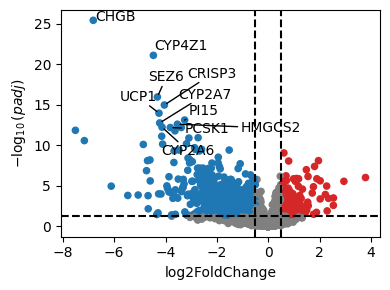

In [44]:
# we can do a volcano plot


# copy svo þú raskir ekki original dataframe
volcano_df = results_df.copy()

# fjarlægja NA symbols
volcano_df = volcano_df.dropna(subset=["SYMBOL"])

# ef sama gene symbol kemur oftar en einu sinni, halda bara einni línu
volcano_df = volcano_df.drop_duplicates(subset=["SYMBOL"])

# setja gene names sem index
volcano_df = volcano_df.set_index("SYMBOL")

# volcano plot með gene names
dc.pl.volcano(
    volcano_df,
    top=10,
    x="log2FoldChange",
    y="padj"
) # change top argument to see top DEGs (based on p.adj)
# we can change x or y (p_adj) from our results_df.columns.

In [46]:
# generate the vector that we want to enrich
# fjarlægja genes sem hafa ekki symbol
df = results_df.dropna(subset=["SYMBOL"]).copy()

# ef sama symbol kemur oftar en einu sinni, halda línu með lægsta padj
df = df.sort_values("padj")
df = df.drop_duplicates(subset="SYMBOL", keep="first")

# setja gene names sem index
df = df.set_index("SYMBOL")

# búa til matrix fyrir enrichment
data = df[["log2FoldChange"]].T.rename(
    index={"log2FoldChange": "disease_vs_normal"}
)

data
# this can be each observation of our adata object (each patient in bulk data for example)


# After performing DEA, we can use the resulting gene-level statistics for enrichment analysis. While any statistic can be used,
# we recommend using t-values rather than log2FCs, as t-values account for the significance of the change.

SYMBOL,CHGB,CYP4Z1,SEZ6,CRISP3,UCP1,PI15,CYP2A7,HMGCS2,CYP2A6,PCSK1,...,GPAT4,ZFP14,RGPD3,ADAMDEC1,CTPS1,ZNF142,GNGT2,HNF4A,COX6A1,DGKB
disease_vs_normal,-6.816878,-4.475083,-4.318788,-4.047427,-4.256864,-3.256274,-4.2301,-3.541004,-4.13851,-3.816383,...,-0.000069,-0.000073,0.000075,-0.000097,0.000041,0.000025,0.000063,-0.000198,-0.000016,0.000044


In [47]:
#Enrichment analysis tests whether a specific set of omics features is “overrepresented” or “coordinated” in the measured data compared to a background distribution.
# We use ULM (Univariate Linear Model) as demonstrated here: https://doi.org/10.1093/bioadv/vbac016 it outperforms methods as GSEA.

#These sets are predefined based on existing biological knowledge and may vary depending on the omics technology used.
collectri = dc.op.collectri(organism="human") # TFs
progeny = dc.op.progeny(organism="human") # signalling pathways
hallmark = dc.op.hallmark(organism="human") # hallmarks

# for more information see the vignette: https://decoupler.readthedocs.io/en/latest/notebooks/scell/rna_psbk.html a brief description for each set of genes is included there.

In [48]:
def enrich(df, net, thr):
  # Run
  tf_acts, tf_padj = dc.mt.ulm(data=df, net=net)
  # Filter by sign padj
  msk = (tf_padj.T < thr).iloc[:, 0]
  tf_acts = tf_acts.loc[:, msk]
  return tf_acts, tf_padj

# we use thr of 0.05 p.adj
thr = 0.05

tf_acts, tf_padj = enrich(data, collectri, thr)
pw_acts, pw_padj = enrich(data, progeny, thr)
hm_acts, hm_padj = enrich(data, hallmark, thr)

In [ ]:
# act -- enrichment score: sign reflects overrepresented (positive) or underrepresented (negative) compared to the background.
# padj -- adjusted p value.

#The scores should be interpreted such that larger magnitudes indicate greater significance

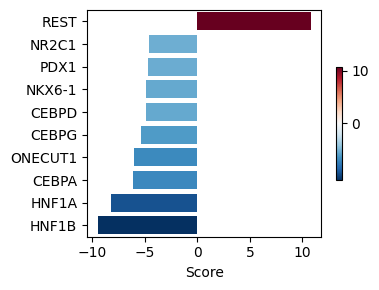

In [49]:
# we can plot our activity results, changing tf_acts or pw_acts or hm_acts
dc.pl.barplot(data=tf_acts, name="disease_vs_normal", top=10, figsize=(4,3)) # changing top argument, we can show more or less.
# Blue bars mean underrepresented sets
# Red bars mean overrepresented sets

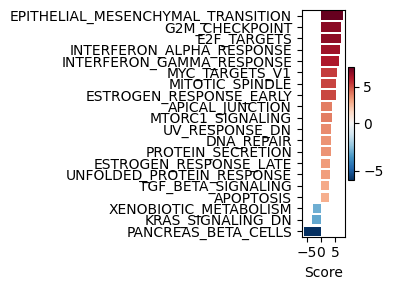

In [50]:
# you can change the input
dc.pl.barplot(data=hm_acts, name="disease_vs_normal", top=20, figsize=(4, 3)) # changing top argument, we can show more or less.


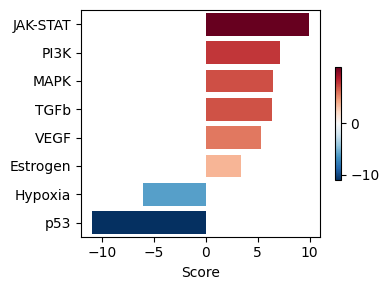

In [53]:
dc.pl.barplot(data=pw_acts, name="disease_vs_normal", top=20, figsize=(4, 3)) # changing top argument, we can show more or less.


Plotting NFkB
Plotting EGFR
Plotting PI3K
Plotting MAPK


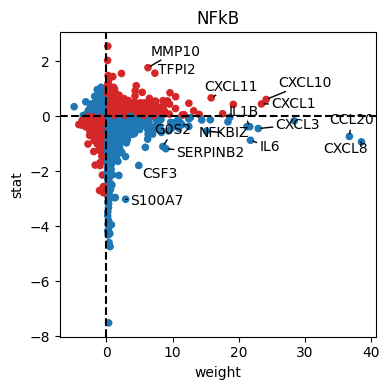

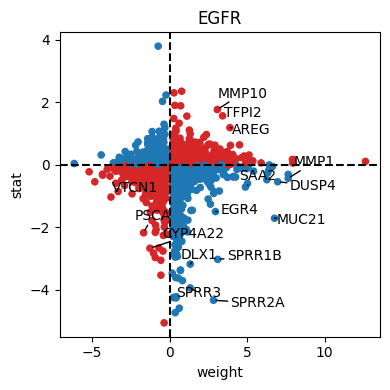

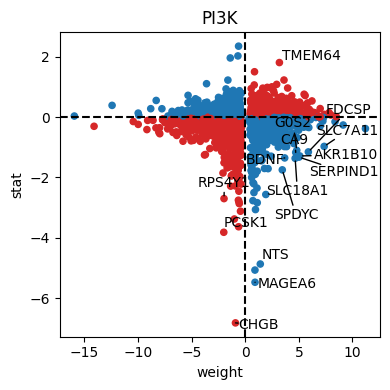

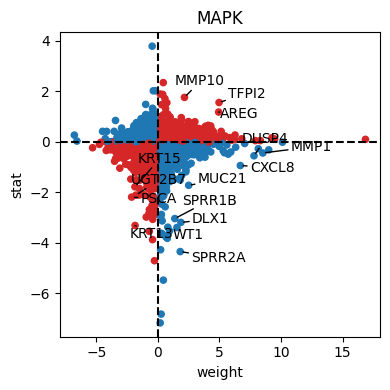

In [56]:
# progeny pathways have weights, we can see from our data the target genes that are enriched.
# change the "name" to the pathway that you want to show, in this case "NFkB" as could be the top upregulated.
# 1) halda bara tölfræðinni úr DE niðurstöðunum
import numpy as np

# setja gene IDs sem index
df = results_df.set_index("SYMBOL")

plot_df = (
    df[["log2FoldChange"]]
    .rename(columns={"log2FoldChange": "stat"})
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

for pw in ["NFkB", "EGFR", "PI3K", "MAPK"]:
    print(f"Plotting {pw}")

    dc.pl.source_targets(
        data=plot_df,
        x="weight",
        y="stat",
        net=progeny,
        name=pw,
        top=15,
        figsize=(4,4)
    )

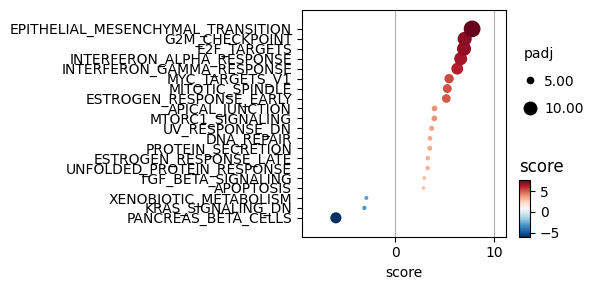

In [57]:
#  We can also do more fancy plots.
df = hm_acts.melt(value_name="score").merge(    # change hm_acts and hm_padj to the pathway that you want to plot.
    hm_padj.melt(value_name="pvalue")
    .assign(padj=lambda x: x["pvalue"].clip(2.22e-16, 1))
    .assign(padj=lambda x: np.log10(x["pvalue"]))
)
dc.pl.dotplot(df=df, x="score", y="variable", s="padj", c="score", top=20, vcenter=0, cmap='RdBu_r', figsize=(6, 3))

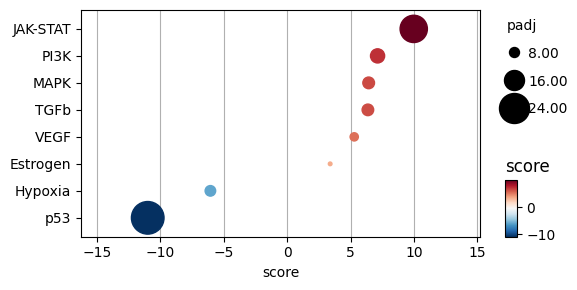

In [58]:
# @title Default title text
df = pw_acts.melt(value_name="score").merge(
    pw_padj.melt(value_name="pvalue")
    .assign(padj=lambda x: x["pvalue"].clip(2.22e-16, 1))
    .assign(padj=lambda x: -np.log10(x["pvalue"]))
)

dc.pl.dotplot(
    df=df,
    x="score",
    y="variable",
    s="padj",
    c="score",
    vcenter=0,
    cmap="RdBu_r",
    figsize=(6,3)
)
#Just the same as the barplot shows above


In [59]:
# choose pathway
pathway = "PI3K"

top_genes = (
    progeny[progeny.source == pathway]
    .sort_values("weight", ascending=False)
    .head(20)
)

top_genes

,source,target,weight,padj
37910,PI3K,C5orf52,12.239809,5.486389e-22
41642,PI3K,PTX3,11.207519,2.703431e-03
39235,PI3K,PSAT1,9.130983,3.232875e-06
38445,PI3K,TUBB2A,8.489069,1.866914e-09
39142,PI3K,F3,8.370580,1.876869e-06
38247,PI3K,TIGAR,7.985892,3.304904e-11
38031,PI3K,GCLM,7.815656,4.580429e-15
39152,PI3K,MTHFD2,7.376769,1.989503e-06
39782,PI3K,SLC7A11,7.358203,3.325256e-05
41809,PI3K,BNIP3,7.300947,3.436182e-03


In [60]:
genes = list(set(top_genes.target) & set(results_df.index))
genes[:10]

[]

In [64]:
df = results_df.copy()

# ef SYMBOL er til
if "SYMBOL" in df.columns:
    df = df.dropna(subset=["SYMBOL"])
    df = df.set_index("SYMBOL")
else:
    df = df.set_index("ENSEMBL")



Genes plotted: 20


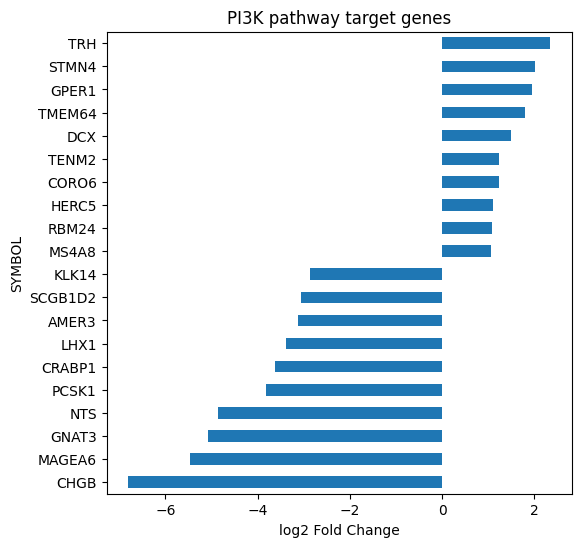

In [70]:
import matplotlib.pyplot as plt

# PI3K genes
genes = progeny.loc[progeny["source"] == "PI3K", "target"].tolist()

# select genes present in dataset
plot_data = df.loc[df.index.intersection(genes)]

# sort by fold change
plot_data = plot_data.sort_values("log2FoldChange")

# taka topp gen fyrir skýrari mynd
plot_data = pd.concat([
    plot_data.head(10),   # most down
    plot_data.tail(10)    # most up
])

print("Genes plotted:", plot_data.shape[0])

plot_data["log2FoldChange"].plot.barh(figsize=(6,6))

plt.xlabel("log2 Fold Change")
plt.title("PI3K pathway target genes")
plt.show()

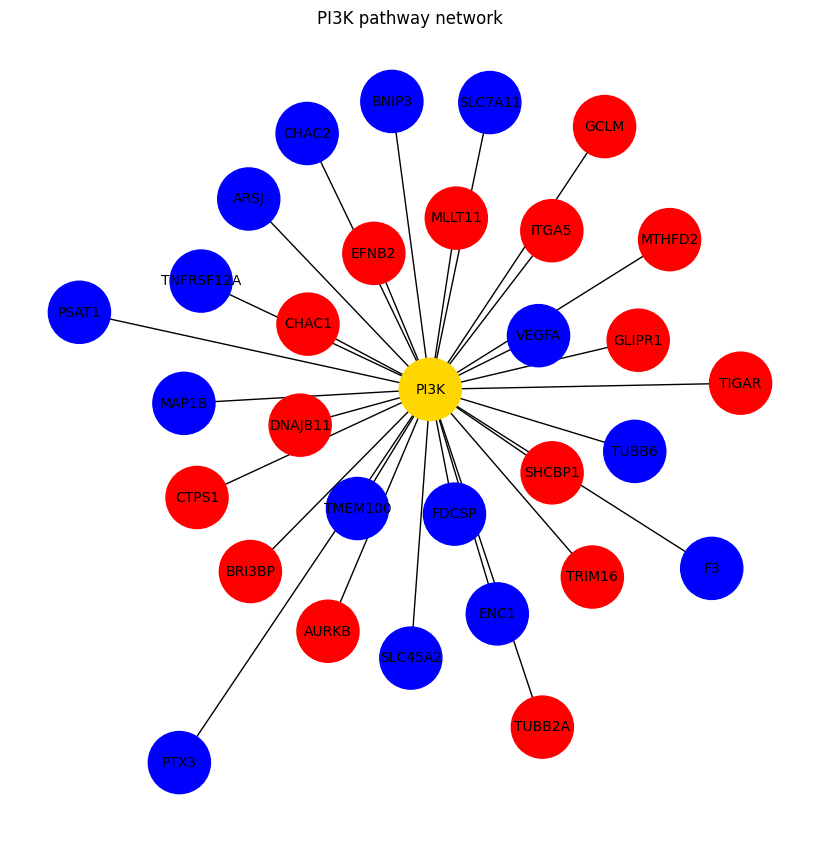

In [73]:
import networkx as nx
import matplotlib.pyplot as plt

# tryggja að gene symbols séu index
df = results_df.dropna(subset=["SYMBOL"]).copy()
df = df.set_index("SYMBOL")

pathway = "PI3K"

# velja pathway úr PROGENy
net = progeny[progeny.source == pathway]

# sameina fold change
net = net.merge(
    df[["log2FoldChange"]],
    left_on="target",
    right_index=True
)

# velja strongest edges
net = net.sort_values("weight", ascending=False).head(30)

# build network
G = nx.from_pandas_edgelist(
    net,
    source="source",
    target="target",
    edge_attr="weight"
)

pos = nx.kamada_kawai_layout(G)

colors = []

for n in G.nodes:

    if n == pathway:
        colors.append("gold")

    elif n in net["target"].values:
        fc = net.set_index("target").loc[n]["log2FoldChange"]
        colors.append("red" if fc > 0 else "blue")

    else:
        colors.append("grey")

plt.figure(figsize=(8,8))

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=2000,
    node_color=colors,
    font_size=10
)

plt.title("PI3K pathway network")
plt.show()